# CRIPSR-Cas Atlas summary

Generate a summary report of all the Cas13b sequences in the CRISPR-Cas atlas.

In [2]:
import modules.atlas_handle as ah
from Bio import SeqIO
import sys
import pandas as pd
import logomaker
import modules.analysis_utils as analysis_utils
from IPython.display import display
from plotnine import (ggplot, aes, geom_histogram, geom_density, theme_bw, 
                      labs, theme, element_text, scale_x_continuous, geom_vline, 
                      geom_boxplot, geom_jitter, scale_x_discrete, stat_summary,
                      scale_y_continuous)
import matplotlib.pyplot as plt
import numpy as np

**Total of 10,097 Cas13 operons**
- 3,743 Cas13b  
- 6,592 Cas13d  
- No Cas13a  
- P5-125 is not in db

Extract Cas13b protein sequences from CRISPR-Cas atlas and format into multifasta file. Set filtering requirement so that only non-truncated sequences are retained and only consider genome sequences for now.

In [8]:
in_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"
out_file = "/spacers_db/crispr-cas-atlas/cas13b_genomes.faa"

# ah.get_protein_sequences(
#     infile=in_file,
#     outfile=out_file)

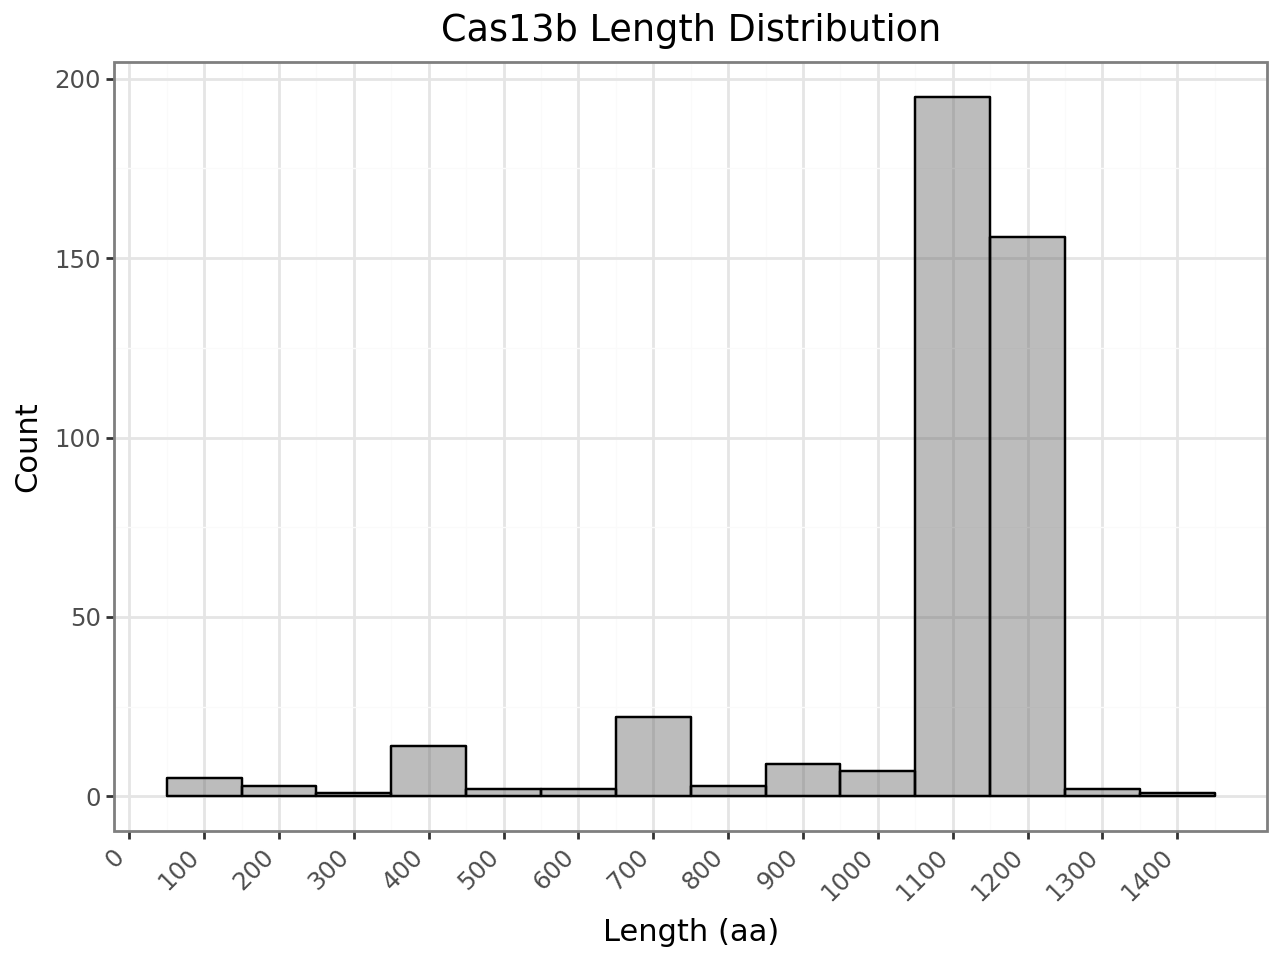

In [34]:
df = pd.DataFrame(columns=["id", "length"])

for record in SeqIO.parse(out_file, "fasta"):
    new_row = {"id": record.id, "length": len(record.seq)}
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


# Ensure numeric dtype
df["length"] = pd.to_numeric(df["length"], errors="coerce").astype("Int64")
df = df.dropna(subset=["length"]).astype({"length": "int64"})

p_freq = (ggplot(df, aes(x='length')) +
    geom_histogram(binwidth=100, position="identity", alpha=0.4, color="black") +
    scale_x_continuous(breaks=range(0, int(df["length"].max()) + 100, 100)) +
    theme_bw() +
    labs(title='Cas13b Length Distribution',
        x='Length (aa)',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )

display(p_freq)

Putative single effector size should be between 900–1,800 aa (informed by the size distribution of previously classified class 2 effectors).

In [35]:
# filter for lengths between 900 and 1800
in_fasta = "/spacers_db/crispr-cas-atlas/cas13b_genomes.faa"
out_fasta = "/spacers_db/crispr-cas-atlas/cas13b_genomes.faa.filtered.faa"

with open(out_fasta, "w") as out_handle:
    for record in SeqIO.parse(in_fasta, "fasta"):
        if 900 <= len(record.seq) <= 1800:
            SeqIO.write(record, out_handle, "fasta")

## Clustering analysis

Since P5-125 (Genbank GCA_000833995.1) is not in the CRISPR-Cas atlas, the sequence had to be retrieved manually and incorporated into the multifasta file.<br>

Use CD-HIT to cluster similar sequences togetherm with a length cut-off of 0.9 and sequence similarity of 0.9.

In [ ]:
# 1) Seed clustering at high identity to reduce redundancy
cd-hit -i /spacers_db/crispr-cas-atlas/cas13b_genomes.faa.filtered.faa \
-o /spacers_db/crispr-cas-atlas/cd-hit/db_80 \
-c 0.8 \
-n 4 \
-g 1 \
-G 0 \
-aS 0.8 \
-d 0 \
-p 1 \
-T 4 \
-M 0 > /spacers_db/crispr-cas-atlas/cd-hit/db_80.log

Perform with all sequences within the CRISPR-Cas atlas.

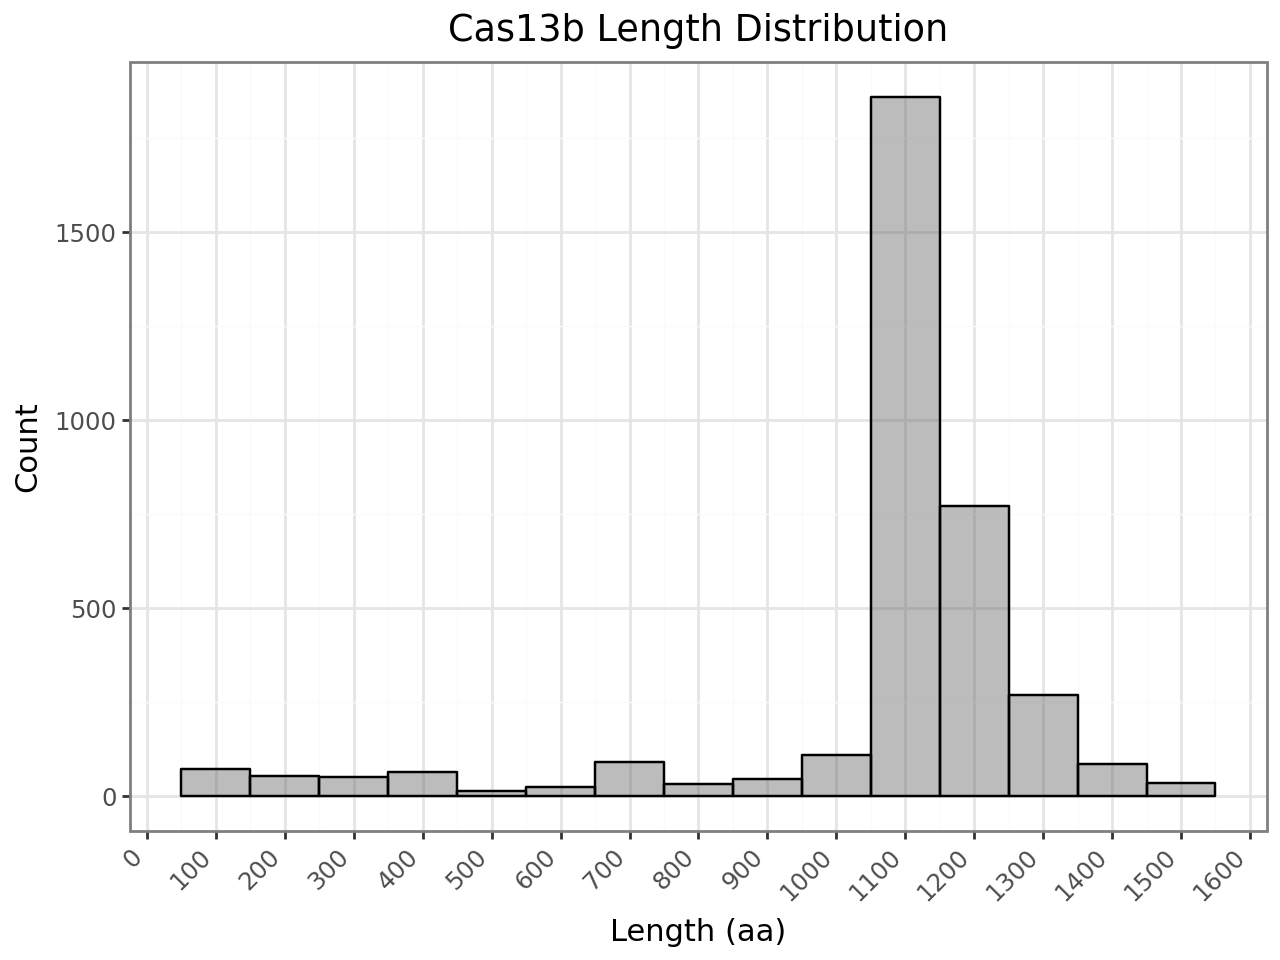

In [4]:
fasta_file = "/spacers_db/crispr-cas-atlas/cas13b_all.faa"

df = pd.DataFrame(columns=["id", "length"])

for record in SeqIO.parse(fasta_file, "fasta"):
    new_row = {"id": record.id, "length": len(record.seq)}
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


# Ensure numeric dtype
df["length"] = pd.to_numeric(df["length"], errors="coerce").astype("Int64")
df = df.dropna(subset=["length"]).astype({"length": "int64"})

p_freq = (ggplot(df, aes(x='length')) +
    geom_histogram(binwidth=100, position="identity", alpha=0.4, color="black") +
    scale_x_continuous(breaks=range(0, int(df["length"].max()) + 100, 100)) +
    theme_bw() +
    labs(title='Cas13b Length Distribution',
        x='Length (aa)',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )

display(p_freq)

In [36]:
# filter for lengths between 900 and 1800
in_fasta = "/spacers_db/crispr-cas-atlas/cas13b_all.faa"
out_fasta = "/spacers_db/crispr-cas-atlas/cas13b_all.faa.filtered.faa"

with open(out_fasta, "w") as out_handle:
    for record in SeqIO.parse(in_fasta, "fasta"):
        if 900 <= len(record.seq) <= 1800:
            SeqIO.write(record, out_handle, "fasta")

In [ ]:
cd-hit -i /spacers_db/crispr-cas-atlas/cas13b_all.faa.filtered.faa \
-o /spacers_db/crispr-cas-atlas/cd-hit_all/db_80 \
-c 0.80 \
-n 5 \
-g 1 \
-G 0 \
-aS 0.9 \
-d 0 \
-p 1 \
-T 16 \
-M 0 > /spacers_db/crispr-cas-atlas/cd-hit_all/db_80.log

Grab sequences that cluster with P5-125

In [ ]:
cluster_file = "/spacers_db/crispr-cas-atlas/cd-hit/db_90.clstr"
fasta_file = "/spacers_db/crispr-cas-atlas/cas13b_all.faa.filtered.faa"
out_fasta = "phylogeny/pspCas13b_cluster.fasta"

cluster_accession_list = ah.extract_from_cdhit_cluster(infile=cluster_file,
                              fasta=fasta_file,
                              ref_accn="GCA_000833995.1_SAMN03284264")

ah.write_fasta_sequences(fasta_file=out_fasta, 
                         target_accns=cluster_accession_list, 
                         outfile=out_fasta)

Align using MAFFT

In [ ]:
mafft --thread 4 --auto phylogeny/pspCas13b_cluster.fasta > phylogeny/pspCas13b_cluster_aligned.fasta

Generate tree from alignment using IQtree (web server)

In [ ]:
# parameters for IQtree
iqtree -s pspCas13b_cluster_aligned.fasta -st AA -m TEST -bb 1000 -alrt 1000

## Spacer sequence analysis

Get spacer sequence from phylogenetically related Cas13b operons

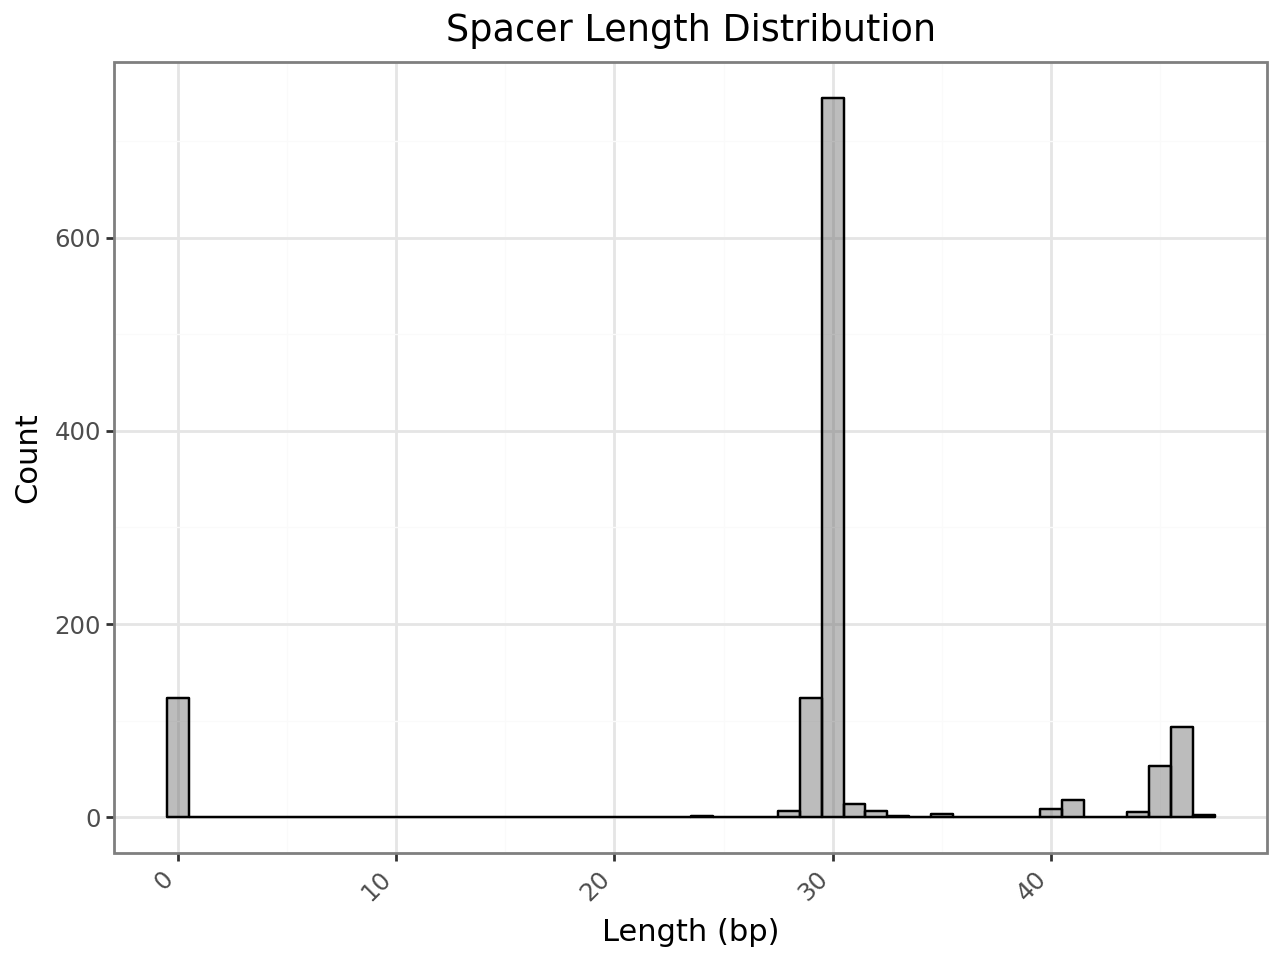

In [62]:
fasta_file = "/spacers_db/crispr-cas-atlas/cas13b_all.faa.filtered.faa"
json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"
acession_list = "/spacers_db/crispr-cas-atlas/cluster3.list"

accessions = [line.strip() for line in open(acession_list)]

spacer_list, spacer_dict = ah.retrieve_spacers(accn_list=accessions, json_file=json_file)

# correct for length variation and orientation of the spacers
consensus_list = ah.generate_spacer_consensus(spacer_list=spacer_list)
final_spacers_list = []
for operon_id, n_spacers in spacer_dict.items():
    for biosample_id, spacers in n_spacers.items():
        corrected_spacers = ah.correct_spacer_sequence(spacers, consensus_list)
        final_spacers_list.extend(corrected_spacers)


# spacer length distribution
df = pd.DataFrame(columns=["spacer", "length"])
for spacer in spacer_list:
    new_row = {"spacer": spacer, "length": len(spacer)}
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df["length"] = pd.to_numeric(df["length"], errors="coerce").astype("Int64")
df = df.dropna(subset=["length"]).astype({"length": "int64"})

p_freq = (ggplot(df, aes(x='length')) +
    geom_histogram(binwidth=1, position="identity", alpha=0.4, color="black") +
    # scale_x_continuous(breaks=range(0, int(df["length"].max()) + 100, 100)) +
    theme_bw() +
    labs(title='Spacer Length Distribution',
        x='Length (bp)',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )

display(p_freq)


Number of gRNA sequences: 225


/tmp/ipykernel_733363/47041053.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


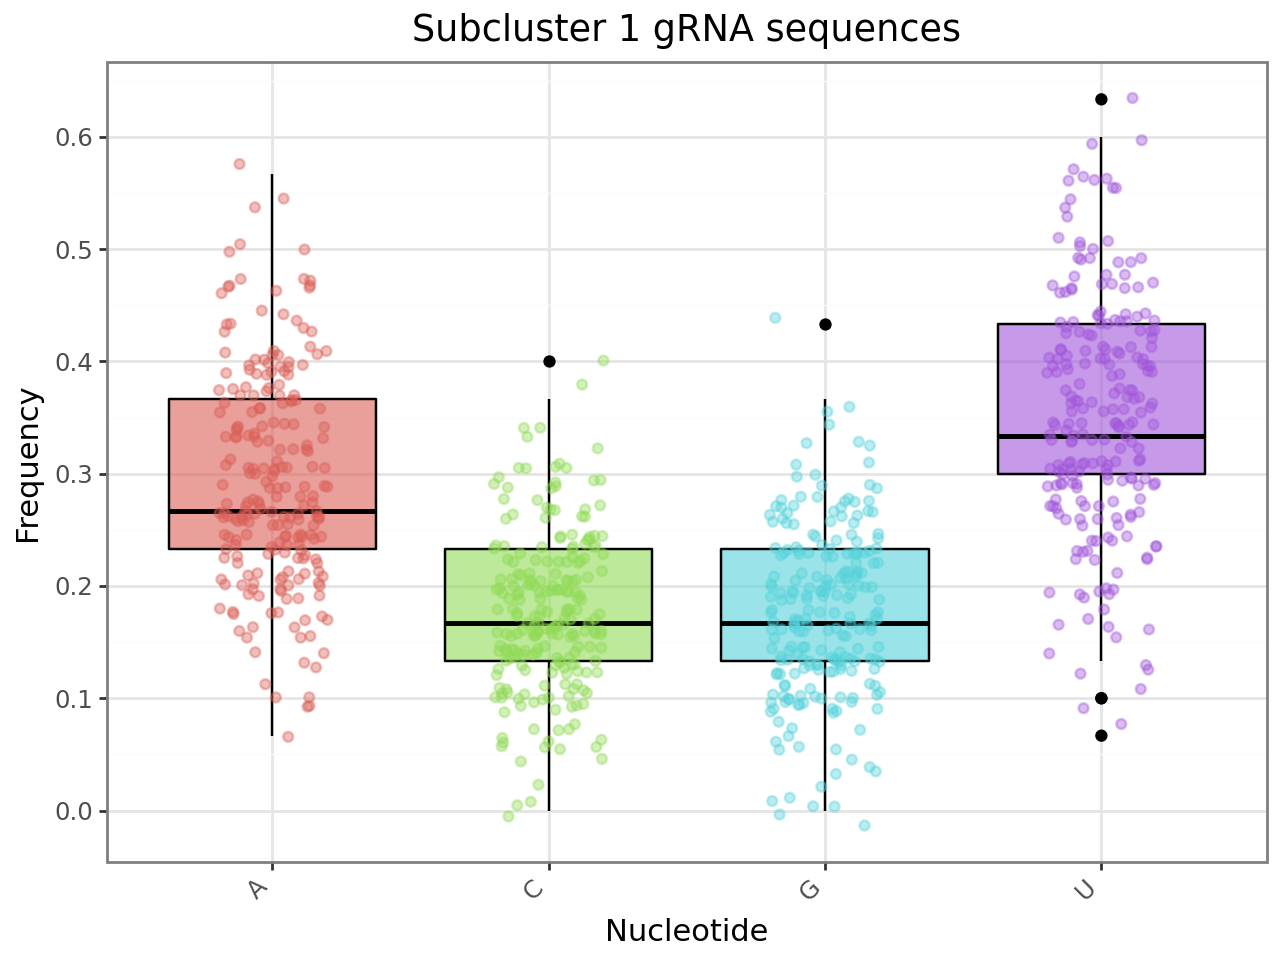

In [63]:
# correct for length variation and orientation of the spacers
consensus_list = ah.generate_spacer_consensus(spacer_list=spacer_list)
final_spacers_list = []
for operon_id, n_spacers in spacer_dict.items():
    for biosample_id, spacers in n_spacers.items():
        corrected_spacers = ah.correct_spacer_sequence(spacers, consensus_list)
        final_spacers_list.extend(corrected_spacers)


filtered_spacer_list = [spacer for spacer in final_spacers_list if len(spacer) == 30]

gRNA_seqs = list(set([analysis_utils.get_gRNA_seq(seq) for seq in filtered_spacer_list]))
n = len(gRNA_seqs)
print(f"Number of gRNA sequences: {n}")

df_nt = pd.DataFrame(columns=['A', 'C', 'G', 'U'])

# calculate nucleotide content for gRNA sequences
for seq in gRNA_seqs:
    nt_content = analysis_utils.nucleotide_content_calc(seq, nt='rna')
    new_row = pd.DataFrame([nt_content])
    df_nt = pd.concat([df_nt, new_row], ignore_index=True)


# Nucleotide frequency plot
df_melt = df_nt.melt(var_name='Variable', value_name='Value')

p_box = (
    ggplot(df_melt, aes(x='Variable', y='Value', fill='Variable')) +
    geom_boxplot(alpha=0.6, color="black") +
    geom_jitter(aes(color='Variable'), alpha=0.4, width=0.2) +
    scale_x_discrete(limits=df_melt['Variable'].unique()) +
    scale_y_continuous(breaks=np.arange(0, df_melt['Value'].max() + 0.1, 0.1)) +
    theme_bw() +
    labs(
        title='Subcluster 1 gRNA sequences',
        x='Nucleotide',
        y='Frequency'
    ) +
    theme(axis_text_x=element_text(rotation=45, hjust=1), legend_position='none')
)

display(p_box)

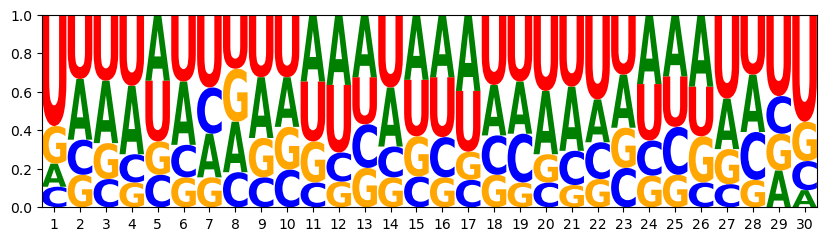

In [64]:

counts_matrix = logomaker.alignment_to_matrix(sequences=gRNA_seqs)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
logo = logomaker.Logo(prob_matrix)
logo.ax.set_xticks(range(prob_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, prob_matrix.shape[0] + 1))

plt.show()

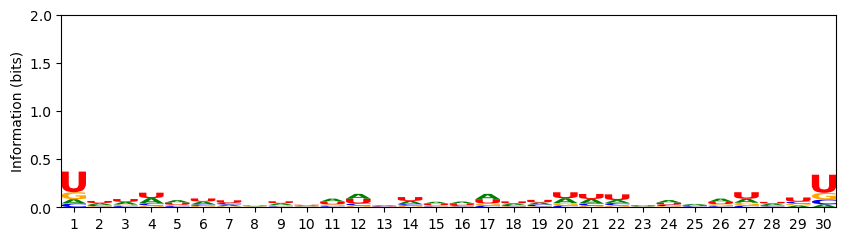

In [65]:
info_matrix = logomaker.transform_matrix(prob_matrix, from_type='probability', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.ax.set_ylabel("Information (bits)")
logo.ax.set_ylim(0, 2)  # Max info per position in DNA is 2 bits
logo.ax.set_xticks(range(info_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, info_matrix.shape[0] + 1))

plt.show()

Get spacer sequences from CD-HIT clusters

Perfrom spacer sequence analysis from phylogenetically related cluster.

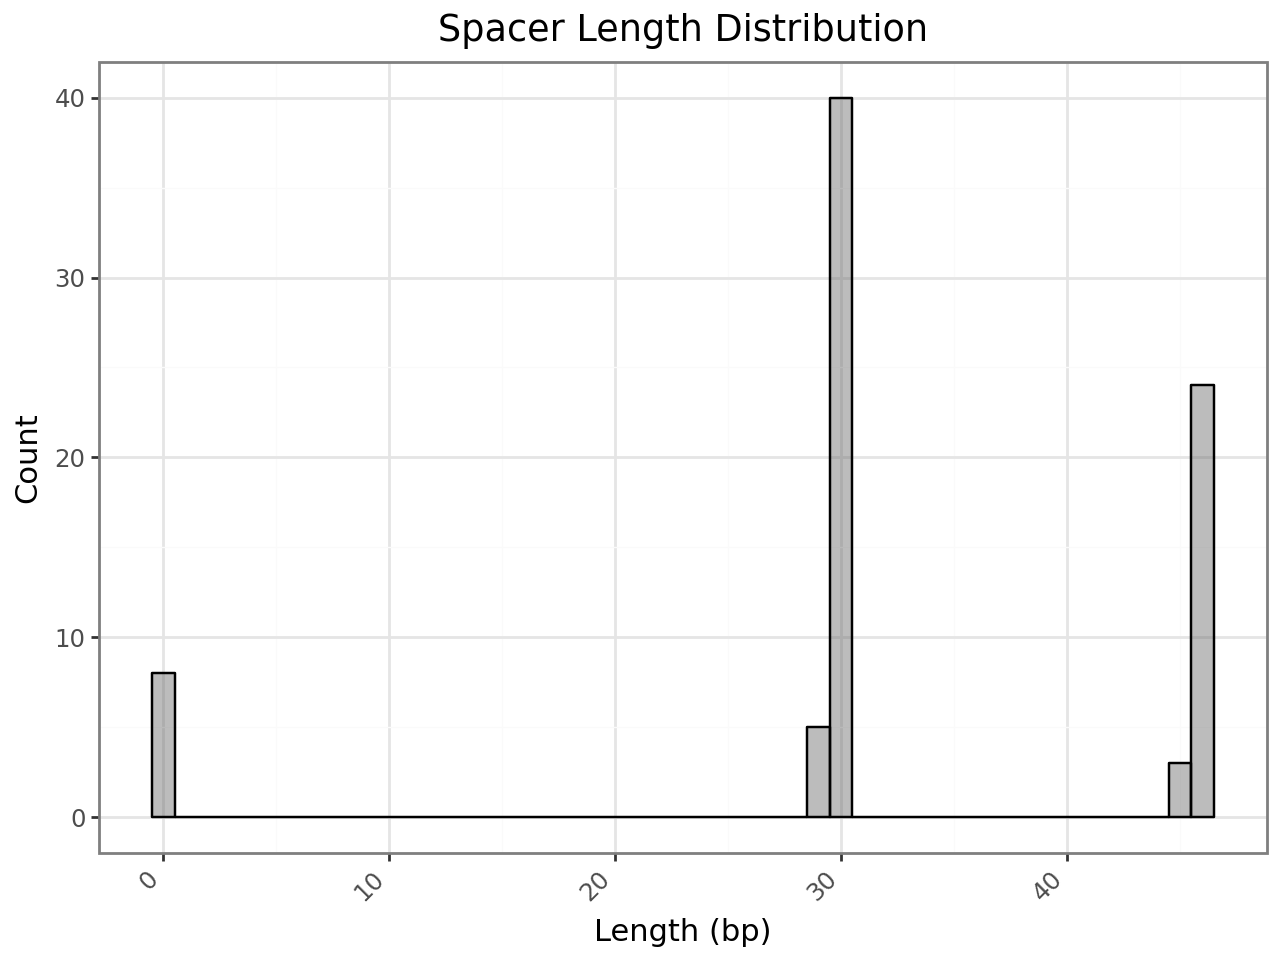

In [24]:
cluster_file = "/spacers_db/crispr-cas-atlas/cd-hit_all/db_98.clstr"
fasta_file = "/spacers_db/crispr-cas-atlas/cas13b_all.faa.filtered.faa"
json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"

ref_accession = "ERZ4561431@44_SAMEA4765810"

cluster_accession_list = ah.extract_from_cdhit_cluster(infile=cluster_file,
                              fasta_file=fasta_file,
                              ref_accn=ref_accession)

spacer_list, spacer_dict = ah.retrieve_spacers(accn_list=cluster_accession_list, json_file=json_file)

# spacer length distribution
df = pd.DataFrame(columns=["spacer", "length"])
for spacer in spacer_list:
    new_row = {"spacer": spacer, "length": len(spacer)}
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df["length"] = pd.to_numeric(df["length"], errors="coerce").astype("Int64")
df = df.dropna(subset=["length"]).astype({"length": "int64"})

p_freq = (ggplot(df, aes(x='length')) +
    geom_histogram(binwidth=1, position="identity", alpha=0.4, color="black") +
    # scale_x_continuous(breaks=range(0, int(df["length"].max()) + 100, 100)) +
    theme_bw() +
    labs(title='Spacer Length Distribution',
        x='Length (bp)',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )

display(p_freq)

80


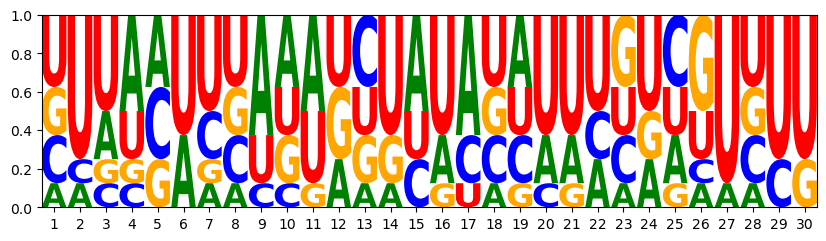

In [27]:
print(len(spacer_list))

# correct for length variation and orientation of the spacers
consensus_list = ah.generate_spacer_consensus(spacer_list=spacer_list)
final_spacers_list = []
for operon_id, n_spacers in spacer_dict.items():
    for biosample_id, spacers in n_spacers.items():
        corrected_spacers = ah.correct_spacer_sequence(spacers, consensus_list)
        final_spacers_list.extend(corrected_spacers)

filtered_spacer_list = [spacer for spacer in final_spacers_list if len(spacer) == 30]

gRNA_seqs = [analysis_utils.get_gRNA_seq(seq) for seq in filtered_spacer_list]
n = len(gRNA_seqs)

counts_matrix = logomaker.alignment_to_matrix(sequences=gRNA_seqs)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
logo = logomaker.Logo(prob_matrix)
logo.ax.set_xticks(range(prob_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, prob_matrix.shape[0] + 1))

plt.show()

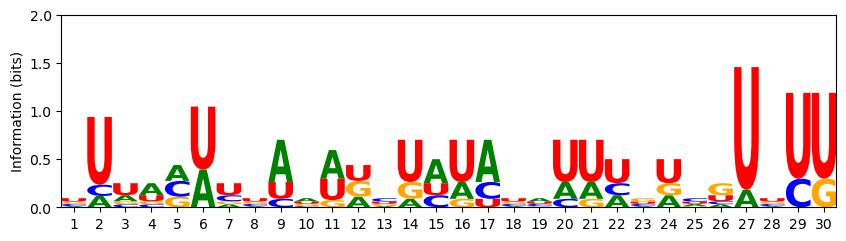

In [26]:
info_matrix = logomaker.transform_matrix(prob_matrix, from_type='probability', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.ax.set_ylabel("Information (bits)")
logo.ax.set_ylim(0, 2)  # Max info per position in DNA is 2 bits
logo.ax.set_xticks(range(info_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, info_matrix.shape[0] + 1))

plt.show()

Get associated repeat sequences for corresponding clusters

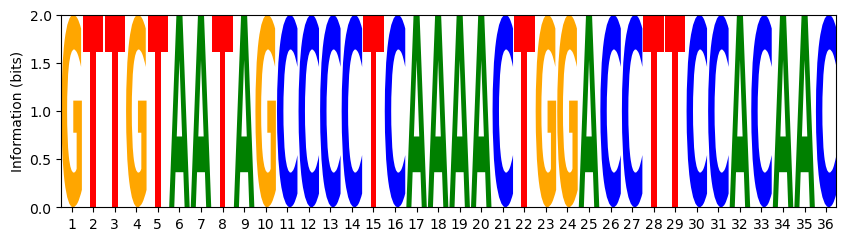

In [10]:
cluster_file = "/spacers_db/crispr-cas-atlas/cd-hit_all/db_98.clstr"
fasta_file = "/spacers_db/crispr-cas-atlas/cas13b_all.faa.filtered.faa"
json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"
ref_accession = "ERZ950874@30_SAMN02334096"

cluster_accession_list = ah.extract_from_cdhit_cluster(infile=cluster_file,
                        fasta_file=fasta_file,
                        ref_accn=ref_accession)

repeat_dict = ah.retrieve_repeat_sequences(accn_list=cluster_accession_list, json_file=json_file)
repeat_list = list(repeat_dict.values())
consensus_list = set(ah.generate_spacer_consensus(spacer_list=repeat_list))

final_repeat_list = [
    (ah.reverse_complement(r) if r not in consensus_list else r)
    for r in repeat_list
    if len(r) == 36
]

counts_matrix = logomaker.alignment_to_matrix(sequences=final_repeat_list)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
info_matrix = logomaker.transform_matrix(prob_matrix, from_type='probability', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.ax.set_ylabel("Information (bits)")
logo.ax.set_ylim(0, 2)  # Max info per position in DNA is 2 bits
logo.ax.set_xticks(range(info_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, info_matrix.shape[0] + 1))

plt.show()

## P5-125 specific clade spacer analysis

Analysing P5-125 specific clade, containing 3 samples in total inlcuding P5-125.

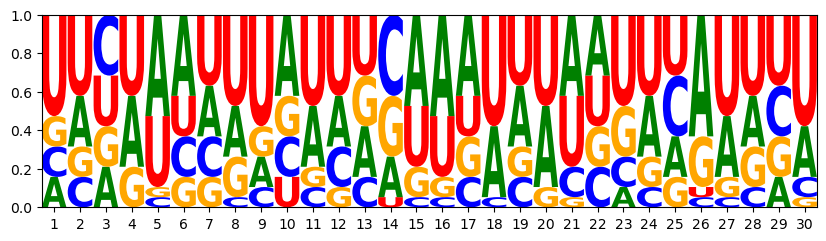

In [52]:
fasta_file = "/spacers_db/crispr-cas-atlas/cas13b_all.faa.filtered.faa"
json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"
acession_list = "/spacers_db/crispr-cas-atlas/P5-125_cluster.list"

accessions = [line.strip() for line in open(acession_list)]

spacers_list, spacer_dict = ah.retrieve_spacers(accn_list=accessions, json_file=json_file)

consensus_list = ah.generate_spacer_consensus(spacer_list=spacers_list)
final_spacers_list = []
for operon_id, n_spacers in spacer_dict.items():
    for biosample_id, spacers in n_spacers.items():
        corrected_spacers = ah.correct_spacer_sequence(spacers, consensus_list)
        final_spacers_list.extend(corrected_spacers)

p5_125_spacers = [ah.reverse_complement(s) for s in ah.P5_125_spacer_seqs()]
final_spacers_list.extend(p5_125_spacers)

filtered_spacer_list = [spacer for spacer in final_spacers_list if len(spacer) == 30]

gRNA_seqs = list(set([analysis_utils.get_gRNA_seq(seq) for seq in filtered_spacer_list]))
n = len(gRNA_seqs)

counts_matrix = logomaker.alignment_to_matrix(sequences=gRNA_seqs)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
logo = logomaker.Logo(prob_matrix)
logo.ax.set_xticks(range(prob_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, prob_matrix.shape[0] + 1))

plt.show()


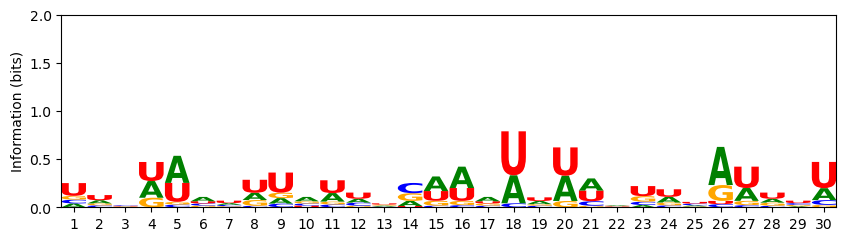

In [11]:
info_matrix = logomaker.transform_matrix(prob_matrix, from_type='probability', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.ax.set_ylabel("Information (bits)")
logo.ax.set_ylim(0, 2)  # Max info per position in DNA is 2 bits
logo.ax.set_xticks(range(info_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, info_matrix.shape[0] + 1))

plt.show()

## P5-125

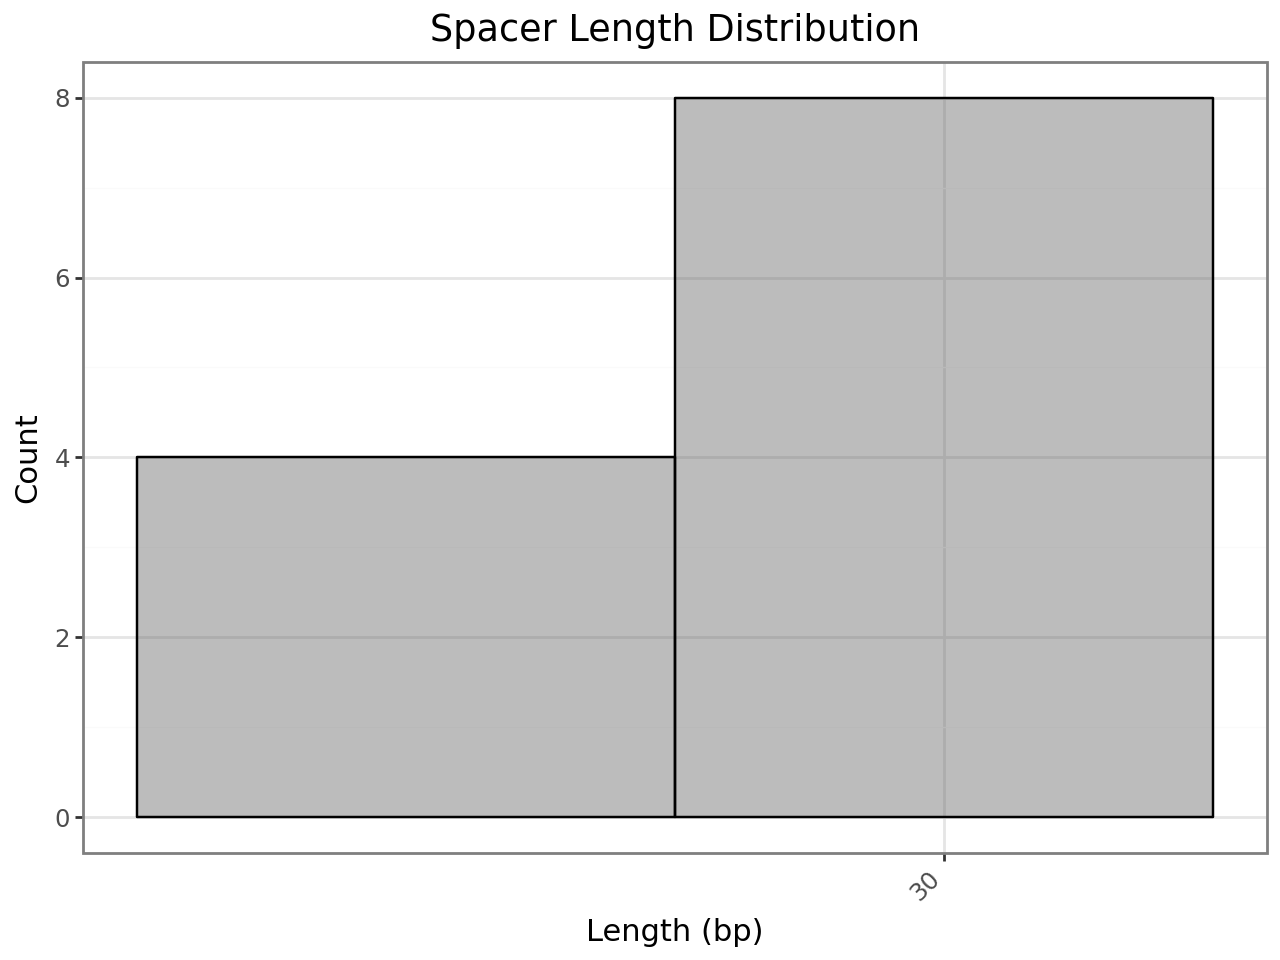

In [76]:

# seqs = ['TCGTTTTGCCCGAGCCAATCAGCAGAAGC', 'TTCTAATAACAATCATTAATCCTTAAAGCA', '', '', '', '']
# p5_125_spacers = [ah.reverse_complement(s) for s in seqs]


p5_125_spacers = [ah.reverse_complement(s) for s in ah.P5_125_spacer_seqs()]

# spacer length distribution
df = pd.DataFrame(columns=["spacer", "length"])
for spacer in p5_125_spacers:
    new_row = {"spacer": spacer, "length": len(spacer)}
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df["length"] = pd.to_numeric(df["length"], errors="coerce").astype("Int64")
df = df.dropna(subset=["length"]).astype({"length": "int64"})


p_freq = (ggplot(df, aes(x='length')) +
    geom_histogram(binwidth=1, position="identity", alpha=0.4, color="black") +
    scale_x_continuous(breaks=range(0, int(df["length"].max()) + 10, 10)) +
    theme_bw() +
    labs(title='Spacer Length Distribution',
        x='Length (bp)',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )

display(p_freq)


4


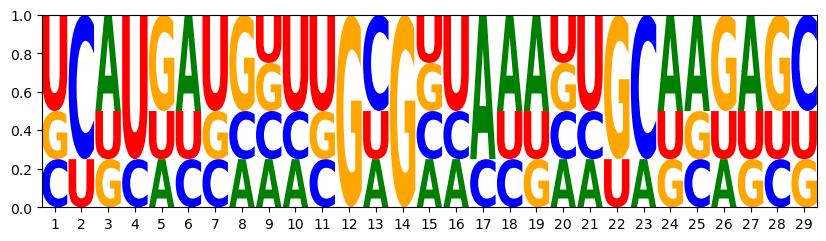

In [ ]:
filtered_spacer_list = [spacer for spacer in p5_125_spacers if len(spacer) == 30]
print(len(filtered_spacer_list))

gRNA_seqs = list(set([analysis_utils.get_gRNA_seq(seq) for seq in filtered_spacer_list]))
n = len(gRNA_seqs)

counts_matrix = logomaker.alignment_to_matrix(sequences=gRNA_seqs)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
logo = logomaker.Logo(prob_matrix)
logo.ax.set_xticks(range(prob_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, prob_matrix.shape[0] + 1))

plt.show()

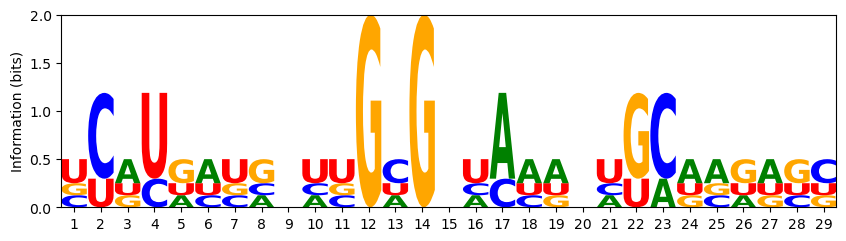

In [79]:
info_matrix = logomaker.transform_matrix(prob_matrix, from_type='probability', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.ax.set_ylabel("Information (bits)")
logo.ax.set_ylim(0, 2)  # Max info per position in DNA is 2 bits
logo.ax.set_xticks(range(info_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, info_matrix.shape[0] + 1))

plt.show()

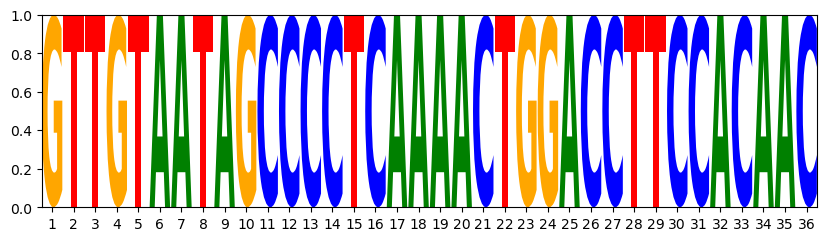

In [13]:
seq = ['GTTGTAATAGCCCCTCAAAACTGGACCTTCCACAAC']
repeat_seq = [s.upper() for s in seq]

counts_matrix = logomaker.alignment_to_matrix(sequences=repeat_seq)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
logo = logomaker.Logo(prob_matrix)
logo.ax.set_xticks(range(prob_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, prob_matrix.shape[0] + 1))

plt.show()

## Test for POI significance

Idenitfied an enrichment As at position 15 and 16 in P5-125 cluster strains. Perform Fisher exact test for these position against all background strains that are not in the P5-125 cluster.

Get spacer sequences from background clade strains.

In [61]:
fasta_file = "/spacers_db/crispr-cas-atlas/cas13b_all.faa.filtered.faa"
json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"
background_strains = "/spacers_db/crispr-cas-atlas/cluster3.list"

accessions = [line.strip() for line in open(background_strains)]

spacer_list, spacer_dict = ah.retrieve_spacers(accn_list=accessions, json_file=json_file)

# correct for length variation and orientation of the spacers
consensus_list = ah.generate_spacer_consensus(spacer_list=spacer_list)
background_strains_spacers = []
for operon_id, n_spacers in spacer_dict.items():
    for biosample_id, spacers in n_spacers.items():
        corrected_spacers = ah.correct_spacer_sequence(spacers, consensus_list)
        background_strains_spacers.extend(corrected_spacers)

background_strains_filt = [spacer for spacer in background_strains_spacers if len(spacer) == 30]
background_gRNA_seqs = list(set([analysis_utils.get_gRNA_seq(seq) for seq in background_strains_filt]))

print(len(background_gRNA_seqs))

225


Get P5-125 cluster strains spacer sequences

In [50]:
json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"
P5_125_strains = "/spacers_db/crispr-cas-atlas/P5-125_cluster.list"

accessions = [line.strip() for line in open(P5_125_strains)]

spacer_list, spacer_dict = ah.retrieve_spacers(accn_list=accessions, json_file=json_file)

# correct for length variation and orientation of the spacers
consensus_list = ah.generate_spacer_consensus(spacer_list=spacer_list)
final_spacers_list = []
for operon_id, n_spacers in spacer_dict.items():
    for biosample_id, spacers in n_spacers.items():
        corrected_spacers = ah.correct_spacer_sequence(spacers, consensus_list)
        final_spacers_list.extend(corrected_spacers)


p5_125_spacers = [ah.reverse_complement(s) for s in ah.P5_125_spacer_seqs()]
final_spacers_list.extend(p5_125_spacers)


filtered_spacer_list = [spacer for spacer in final_spacers_list if len(spacer) == 30]

p5_125_gRNA_seqs = list(set([analysis_utils.get_gRNA_seq(seq) for seq in filtered_spacer_list]))



19


Perform Fisher exact test for position 15 and 16

In [23]:
print(analysis_utils.perform_fishers_test(p5_125_gRNA_seqs, background_gRNA_seqs, position=16, nucleotide='A'))

(7, 12, 59, 166, np.float64(0.4188559660557797))


# Other orthologs

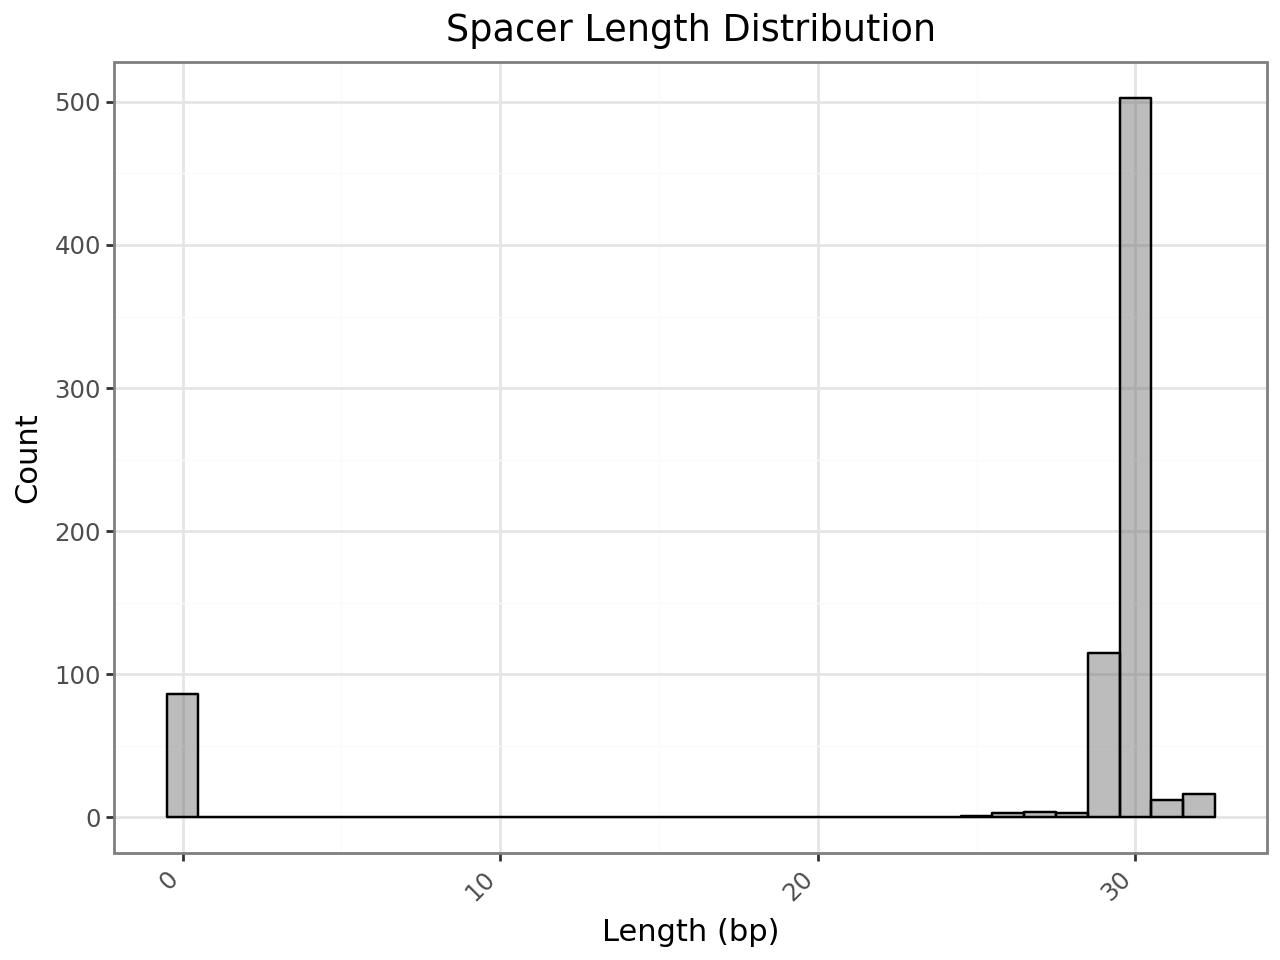

In [80]:
cluster_file = "/spacers_db/crispr-cas-atlas/cd-hit_all/db_98.clstr"
fasta_file = "/spacers_db/crispr-cas-atlas/cas13b_all.faa.filtered.faa"
json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"
ref_accession = "GCA_018141745.1@17_SAMN18805464"

cluster_accession_list = ah.extract_from_cdhit_cluster(infile=cluster_file,
                              fasta_file=fasta_file,
                              ref_accn=ref_accession)

spacer_list, spacer_dict = ah.retrieve_spacers(accn_list=cluster_accession_list, json_file=json_file)

# spacer length distribution
df = pd.DataFrame(columns=["spacer", "length"])
for spacer in spacer_list:
    new_row = {"spacer": spacer, "length": len(spacer)}
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df["length"] = pd.to_numeric(df["length"], errors="coerce").astype("Int64")
df = df.dropna(subset=["length"]).astype({"length": "int64"})

p_freq = (ggplot(df, aes(x='length')) +
    geom_histogram(binwidth=1, position="identity", alpha=0.4, color="black") +
    # scale_x_continuous(breaks=range(0, int(df["length"].max()) + 100, 100)) +
    theme_bw() +
    labs(title='Spacer Length Distribution',
        x='Length (bp)',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )

display(p_freq)

Number of spacers retrieved: 743
Number of gRNA sequences: 202


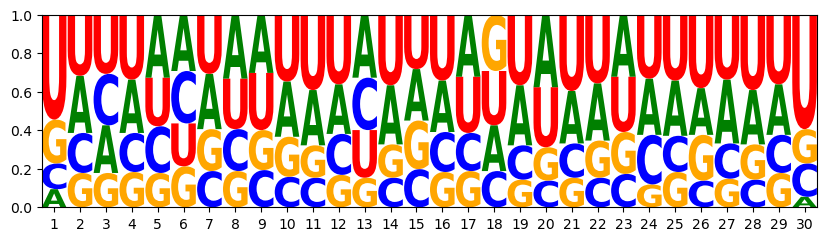

In [81]:
print(f"Number of spacers retrieved: {len(spacer_list)}")

# correct for length variation and orientation of the spacers
consensus_list = ah.generate_spacer_consensus(spacer_list=spacer_list)
final_spacers_list = []
for operon_id, n_spacers in spacer_dict.items():
    for biosample_id, spacers in n_spacers.items():
        corrected_spacers = ah.correct_spacer_sequence(spacers, consensus_list)
        final_spacers_list.extend(corrected_spacers)

filtered_spacer_list = [spacer for spacer in final_spacers_list if len(spacer) == 30]

gRNA_seqs = list(set([analysis_utils.get_gRNA_seq(seq) for seq in filtered_spacer_list]))
n = len(gRNA_seqs)
print(f"Number of gRNA sequences: {n}")

counts_matrix = logomaker.alignment_to_matrix(sequences=gRNA_seqs)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
logo = logomaker.Logo(prob_matrix)
logo.ax.set_xticks(range(prob_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, prob_matrix.shape[0] + 1))

plt.show()

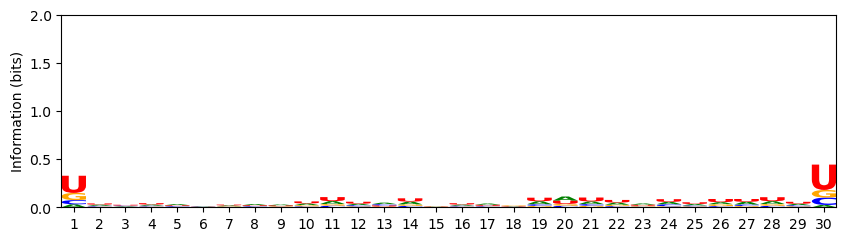

In [82]:
info_matrix = logomaker.transform_matrix(prob_matrix, from_type='probability', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.ax.set_ylabel("Information (bits)")
logo.ax.set_ylim(0, 2)  # Max info per position in DNA is 2 bits
logo.ax.set_xticks(range(info_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, info_matrix.shape[0] + 1))

plt.show()